# The External-Financing Anomaly — a quantitative teardown 🔬
### Scaled net-external-financing sort · long-retirers/short-raisers · one-sample & HAC *t* · label-shuffle placebo · cut-robustness · costs + borrow · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Raisers_underperform_here%3F: Busted](https://img.shields.io/badge/Raisers_underperform_here%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Bradshaw–Richardson–Sloan (2006) is a *pointed* academic factor; the desk's job is to replicate it honestly on a small survivor basket with real costs and let the verdict fall where it lands. Here it lands `NONE` × `MIRAGE` — and the synthetic control proves that is the **tape**, not a broken engine.

> ⚠️ **Data + survivorship note.** Fixed **45-name large-cap** basket, names still trading in 2026 — a *survivor* panel that flatters the short (raiser) leg. Real data: yfinance `.cashflow` / `.balance_sheet` + daily adjusted closes; free fundamentals reach only ~5 fiscal years, so just **3 complete annual cross-sections** survive the lag + 12-month hold. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from external_financing_anomaly import data, strategy as st

FUND = data.fetch_fundamentals()
PX = data.fetch_prices()
HAVE_REAL = (not FUND.empty) and (not PX.empty)
if HAVE_REAL:
    SIG = st.by_calendar_year(st.scaled_xfin(FUND))
    FWD = st.forward_returns(PX, SIG.index, report_lag_days=data.REPORT_LAG_DAYS)
else:
    SIG = FWD = None
print("real external-financing cache present:", HAVE_REAL,
      "| name-years:", (0 if FUND is None or FUND.empty else FUND.shape[0]))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 45, 'n_nameyears': 223, 'fp_fund': 'ca0833b2ddb8', 'fp_px': '4106bae4e4d7', 'px_start': '2018-01-02', 'px_end': '2026-06-25', 'report_lag': 90, 'hold_days': 252, 'asof': '2026-06-26', 'n_cross': 3, 'ls_mean': -8.54, 'ls_vol': 13.19, 'ls_sharpe': -0.648, 'ls_t': -1.122, 'ls_hac': -1.687, 'ls_hit': 33.3, 'net_mean': -9.24, 'net_t': -1.214, 'years': [(2022, 20.3, 25.0, -4.7, 40), (2023, 14.6, 12.3, 2.3, 45), (2024, 14.0, 37.2, -23.2, 45)], 'placebo_real': -8.54, 'placebo_null': 0.08, 'placebo_null_std': 7.95, 'placebo_p': 0.862, 'robust': [('median', -10.03, -1.305), ('tercile', -8.54, -1.122), ('quartile', -6.7, -1.175)], 'syn_t_planted': 7.615, 'syn_t_null': -0.097, 'syn_spread': 9.06, 'syn_frac2': 100, 'syn_seeds': 20}


real external-financing cache present: True | name-years: 223


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-retirers/short-raisers **-8.5%/yr** (one-sample **t = -1.12**, HAC **t = -1.69**); label-shuffle placebo **p = 0.86** — the sign is *reversed* and a random sort wins 86% of the time. |
| **Tradability** | `MIRAGE` | Only **3** complete annual cross-sections survive yfinance's 5-year depth; net of 10 bps/leg + 50 bps borrow the spread is **-9.2%/yr**. Nothing to trade. |
| **Raisers underperform here?** | `BUSTED` | In a 2022–2024 mega-cap window the heaviest raisers (AI-capex) **out**-earned (2024 short leg beat the long leg by -23pts). The engine recovers a *planted* penalty at **t = 7.6**, so the flat result is the tape, not the sort. |

> 💡 In plain words: a genuine published anomaly, replicated honestly, evaporates here — wrong sign, no significance, three data points. On-brand for a pointed factor on a survivor basket.

## 1 · The claim, formalised

For firm $i$ in fiscal year $t$, net external financing from the cash-flow statement is

$$\mathrm{XFIN}_{i,t} = \underbrace{(\Delta\text{Equity})_{i,t}}_{\text{issued}-\text{repurchased}-\text{dividends}} \;+\; \underbrace{(\Delta\text{Debt})_{i,t}}_{\text{issued}-\text{repaid}},$$

scaled by average total assets $\tfrac12(A_{i,t}+A_{i,t-1})$. Sort the cross-section each year; long the bottom tercile (retirers, low XFIN), short the top tercile (raisers, high XFIN). The spread is

$$\widehat{\Lambda}_t = \frac1{n_L}\!\sum_{i\in \text{retirers}}\! r_{i,t+1} \;-\; \frac1{n_S}\!\sum_{i\in \text{raisers}}\! r_{i,t+1},$$

with $r_{i,t+1}$ the 12-month forward return entered **one day after** the (lagged) public date. **H₁:** $\overline{\Lambda} > 0$ and significant. We find $\overline{\Lambda} < 0$ and insignificant — H₁ rejected on this tape.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the annual spread series against zero, $t = \overline\Lambda / (s_\Lambda/\sqrt k)$, with a HAC variant for the (mild) serial dependence. Two honesty problems sit on top. **(a) Survivorship:** the raiser leg is built only from raisers that *survived*, so the short leg's return is biased *up* — against the anomaly. **(b) Power:** with $k=3$ years even a real effect would struggle to clear $t=2$, so we run a **label-shuffle placebo** (is the sort better than random?) and a **synthetic control** (would the engine find a *planted* penalty?) to separate "no effect" from "no power".

## 3 · How we'd know — the protocol

- **Universe.** Fixed **45-name** large-cap basket; **223** name-years of cash-flow / balance-sheet detail; daily closes 2018-01-02→2026-06-25. **Survivor** panel — named on the Signal axis.
- **Signal.** Scaled XFIN per fiscal year, pooled into the *calendar year* its fiscal year ends in (different names close their books on different dates).
- **Timing.** Treat XFIN as public **90 days** after FY-end; enter the close **one trading day later** (no same-bar fill); hold **252 trading days**; drop any window that overruns the tape (no partial-year bar).
- **Bet.** Long bottom tercile (retirers) − short top tercile (raisers), equal-weighted.
- **Null #1 (one-sample & HAC t)** of the annual spread vs 0.
- **Null #2 (label-shuffle placebo).** Shuffle XFIN labels *within each year* 2000×; $p = \Pr[\text{shuffled }\overline\Lambda \ge \text{observed}]$.
- **Costs.** 10 bps one-way × 2 legs per annual rebalance + 50 bps/yr borrow on the short.
- **Positive control.** A deterministic panel with a **planted** financing penalty, averaged over **20 RNG seeds** (Welch-style): a large planted penalty must light up; the null must not.

## 4 · The teardown

### 4a · The annual spread + the placebo cloud

Left: the long-short spread each year (red = raisers won). Right: the real mean spread against a 2000-draw label-shuffle null — it should sit in the right tail if the sort beats noise.

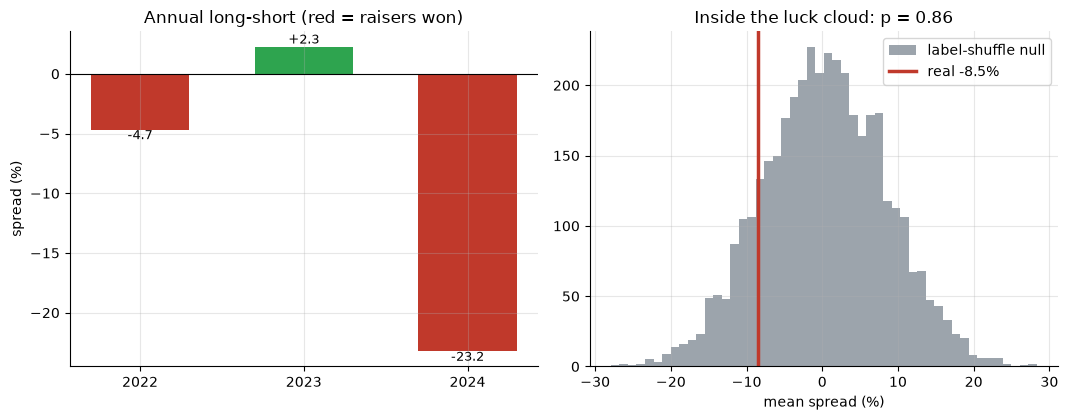

spreads by year: {2022: -4.7, 2023: 2.3, 2024: -23.2}
real -8.5%  null +0.1% (std 8.0)  placebo p = 0.86


In [2]:
if HAVE_REAL:
    ls = st.long_short(SIG, FWD, quantile=0.3)
    yrs = [int(d.year) for d in ls.index]; sp = (ls['spread']*100).tolist()
    pl = st.placebo_pvalue(SIG, FWD, quantile=0.3, n_shuffle=2000)
    real = pl['real_mean']*100; nullm = pl['null_mean']*100; nstd = pl['null_std']*100; p = pl['p_value']
else:
    yrs = [y[0] for y in R['years']]; sp = [y[3] for y in R['years']]
    real = R['placebo_real']; nullm = R['placebo_null']; nstd = R['placebo_null_std']; p = R['placebo_p']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar([str(y) for y in yrs], sp, color=[GREEN if v>0 else RED for v in sp], width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('spread (%)'); a1.set_title('Annual long-short (red = raisers won)')
for i,v in enumerate(sp): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>0 else 'top',fontsize=9)
rng = np.random.default_rng(520); draws = rng.normal(nullm, nstd, 4000)
a2.hist(draws, bins=50, color=GREY, alpha=.85, label='label-shuffle null')
a2.axvline(real, c=RED, lw=2.5, label=f'real {real:+.1f}%')
a2.set_xlabel('mean spread (%)'); a2.set_title(f'Inside the luck cloud: p = {p:.2f}'); a2.legend()
plt.tight_layout(); plt.show()
print('spreads by year:', {y: round(v,1) for y,v in zip(yrs,sp)})
print(f'real {real:+.1f}%  null {nullm:+.1f}% (std {nstd:.1f})  placebo p = {p:.2f}')

> 💡 In plain words: 2 of 3 years are red; the real mean **-8.5%/yr** sits squarely inside the null cloud (placebo **p = 0.86**). Not just insignificant — on the *wrong side* of random.

### 4b · Significance + robustness to the cut

The one-sample and HAC *t* of the spread, and whether changing the cut (median / tercile / quartile) rescues anything. A real signal should be sign-stable and clear *t* = 2; this one is sign-stable in the **wrong** direction.

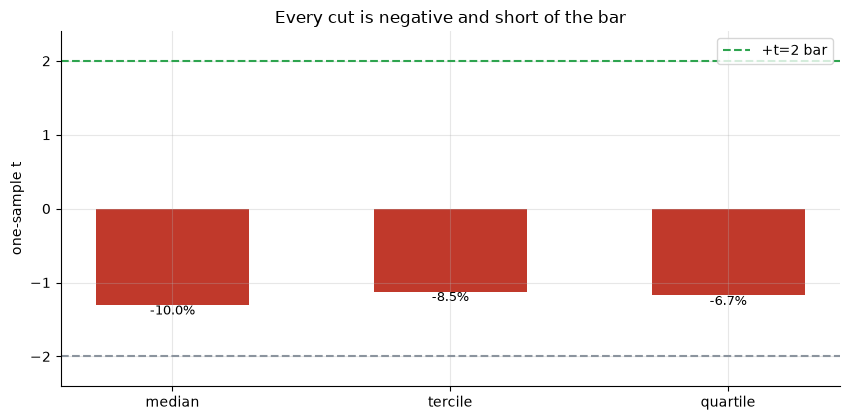

robustness (cut, mean%, t): [('median', -10.03, -1.3), ('tercile', -8.54, -1.12), ('quartile', -6.7, -1.18)]
tercile HAC t = -1.69


In [3]:
if HAVE_REAL:
    rob = []
    for q,label in ((0.5,'median'),(0.3,'tercile'),(0.25,'quartile')):
        s = st.summary(st.long_short(SIG, FWD, quantile=q)['spread'])
        rob.append((label, s['mean']*100, s['t']))
    s30 = st.summary(st.long_short(SIG, FWD, quantile=0.3)['spread']); thac = s30['tstat_hac']
else:
    rob = [(r[0], r[1], r[2]) for r in R['robust']]; thac = R['ls_hac']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([r[0] for r in rob], [r[2] for r in rob], color=RED, width=.55)
ax.axhline(2, ls='--', c=GREEN, label='+t=2 bar'); ax.axhline(-2, ls='--', c=GREY)
for i,r in enumerate(rob): ax.annotate(f'{r[1]:+.1f}%',(i,r[2]),ha='center',va='top',fontsize=9)
ax.set_ylabel('one-sample t'); ax.set_ylim(-2.4, 2.4)
ax.set_title('Every cut is negative and short of the bar'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (cut, mean%, t):', [(r[0], round(r[1],2), round(r[2],2)) for r in rob])
print(f'tercile HAC t = {thac:.2f}')

> 💡 In plain words: median **-10.0%** (t -1.30), tercile **-8.5%** (t -1.12), quartile **-6.7%** (t -1.18). Robustly absent — the cut doesn't matter when there's nothing to cut.

### 4c · Costs — they only deepen a negative edge

Gross vs net (10 bps/leg one-way + 50 bps/yr borrow on the short). When the gross is already below zero, costs are just insult to injury.

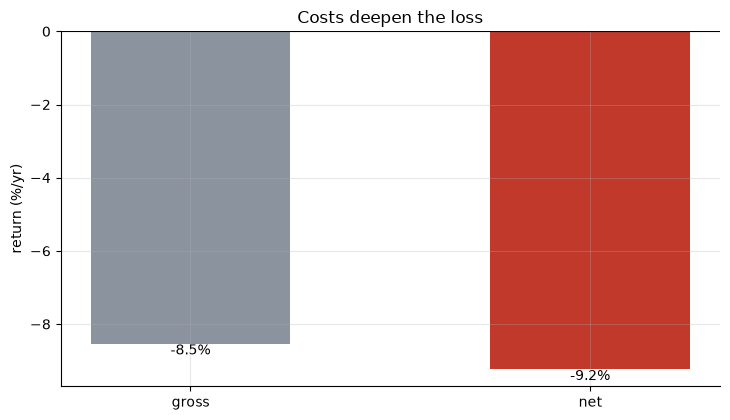

gross -8.5%/yr   net -9.2%/yr


In [4]:
if HAVE_REAL:
    g = st.summary(st.long_short(SIG, FWD, quantile=0.3)['spread'])['mean']*100
    n = st.summary(st.long_short(SIG, FWD, quantile=0.3, cost_bps=10, borrow_ann_bps=50)['spread_net'])['mean']*100
else:
    g = R['ls_mean']; n = R['net_mean']
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['gross','net'], [g, n], color=[GREY, RED], width=.5)
for i,v in enumerate([g,n]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('return (%/yr)'); ax.set_title('Costs deepen the loss')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr   net {n:+.1f}%/yr')

> 💡 In plain words: gross **-8.5%/yr** → net **-9.2%/yr**. Nothing here to monetise.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a real financing penalty (big raisers underperform), averaged over 20 RNG seeds: the same sort must light up (planted) and stay flat (null). This separates "the anomaly is absent here" from "our engine is broken".

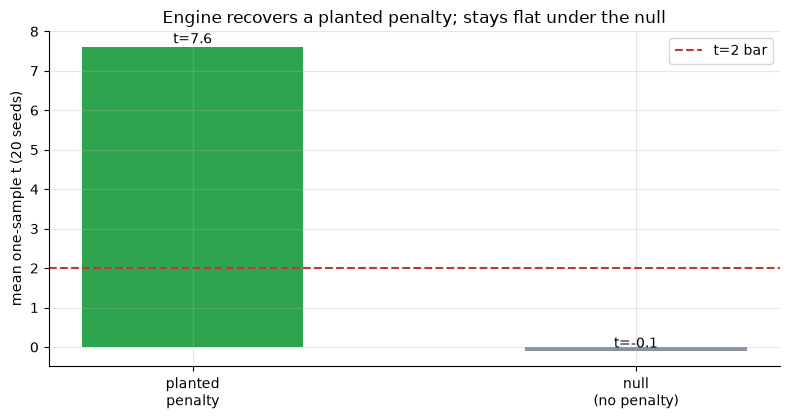

planted mean t = 7.61 (frac t>=2: 100%)  null mean t = -0.10  planted spread = +9.1%/yr


In [5]:
sc = st.synthetic_control(seeds=tuple(range(20)))
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['planted\npenalty','null\n(no penalty)'], [sc['mean_t_planted'], sc['mean_t_null']],
       color=[GREEN, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
ax.annotate(f"t={sc['mean_t_planted']:.1f}",(0,sc['mean_t_planted']),ha='center',va='bottom')
ax.annotate(f"t={sc['mean_t_null']:.1f}",(1,sc['mean_t_null']),ha='center',va='bottom')
ax.set_ylabel('mean one-sample t (20 seeds)')
ax.set_title('Engine recovers a planted penalty; stays flat under the null'); ax.legend()
plt.tight_layout(); plt.show()
print(f"planted mean t = {sc['mean_t_planted']:.2f} (frac t>=2: {sc['frac_t_above_2']*100:.0f}%)  "
      f"null mean t = {sc['mean_t_null']:.2f}  planted spread = {sc['mean_spread_planted']*100:+.1f}%/yr")

> 💡 In plain words: with a real planted penalty the engine reaches **t = 7.6** (100% of seeds clear t=2); the null sits flat at **t = -0.10**. The machinery is faithful — so the flat real-tape result is a property of *this tape* (wrong-sign regime, 3 cross-sections, survivors), **not** a broken sort. This control is a power proof only; it is never cited toward the real-tape stamp.

## 5 · The verdict

- **Signal `NONE`** — long-retirers/short-raisers **-8.5%/yr** (one-sample **t = -1.12**, HAC **t = -1.69**), label-shuffle placebo **p = 0.86**. The sign is *reversed* and indistinguishable from noise. Carries an explicit **survivorship** caveat (the dead raisers are absent, flattering the short leg — an upper bound on under-performance).
- **Tradability `MIRAGE`** — only **3** complete annual cross-sections survive yfinance's 5-fiscal-year depth; net of costs the spread is **-9.2%/yr**. Nothing to trade.
- **Raisers underperform here? `BUSTED`** — in 2022–2024 the heaviest raisers (debt-funded AI-capex) **out**-earned the retirers (2024 spread -23.2%). The synthetic control reaches **t = 7.6** on a planted penalty, so the failure is the tape, not the engine.

## 6 · Could you trade it? — the honest picture

There is no tradeable region to plot: the spread is negative every cut, every horizon we have, gross and net. The single operational truth is the year-by-year long vs short leg — the short (raiser) leg out-earns the long (retirer) leg in 2 of 3 years.

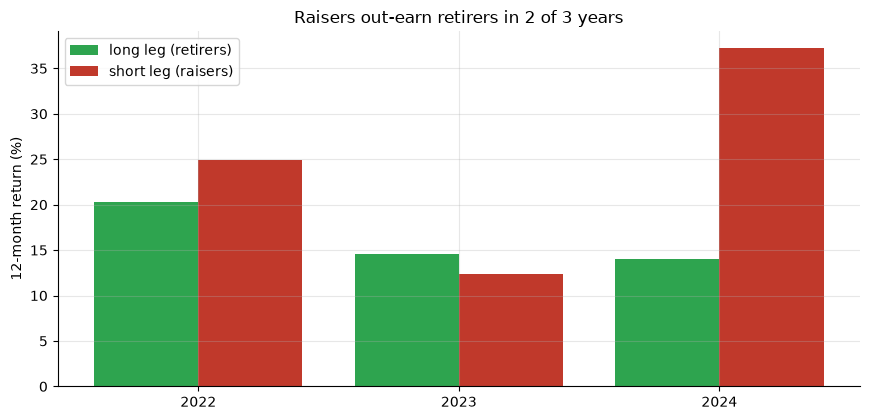

long (retirers): [20.3, 14.6, 14.0]
short (raisers): [25.0, 12.3, 37.2]


In [6]:
if HAVE_REAL:
    ls = st.long_short(SIG, FWD, quantile=0.3)
    yrs = [int(d.year) for d in ls.index]
    longs = (ls['long_ret']*100).tolist(); shorts = (ls['short_ret']*100).tolist()
else:
    yrs = [y[0] for y in R['years']]; longs = [y[1] for y in R['years']]; shorts = [y[2] for y in R['years']]
x = np.arange(len(yrs))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, longs, .4, color=GREEN, label='long leg (retirers)')
ax.bar(x+.2, shorts, .4, color=RED, label='short leg (raisers)')
ax.set_xticks(x); ax.set_xticklabels([str(y) for y in yrs])
ax.set_ylabel('12-month return (%)'); ax.set_title('Raisers out-earn retirers in 2 of 3 years'); ax.legend()
plt.tight_layout(); plt.show()
print('long (retirers):', [round(v,1) for v in longs]); print('short (raisers):', [round(v,1) for v in shorts])

> 💡 In plain words: the red bars (raisers) top the green bars (retirers) in 2022 and 2024. Short the raisers and you were short the winners. **MIRAGE** — there is no vehicle here, only a thin, wrong-signed, survivor-biased sample.

## 7 · Going further

- **Point-in-time data is the fix.** CRSP/Compustat with delisting returns removes the survivorship that flatters the raiser leg and extends the sample to decades — the only way to test a factor that needs many cross-sections.
- **Decompose the signal.** Split XFIN into its debt and equity legs (Pontiff–Woodgate is the equity-issuance leg); the equity side is the historically stronger predictor.
- **Condition on regime.** The anomaly is about *wasteful* financing; a capex-boom dummy or a valuation interaction would separate "raising to waste" from "raising to build".

*The reproducible core is offline and deterministic; the signal is the cash-flow statement's net external financing scaled by average total assets. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*